# Mapping MeSH descriptors to AOP Key Events (KEs)

#### Goal

Map MeSH descriptors to KEs from the AOP-Wiki database using Natural Language Processing, semantic search and indexing to identify correspondences between MeSH descriptors and AOP Key Events.

#### AOP Key Events 

- Extracted from AOP-Wiki  
- Includes KEs with detailed textual descriptions capturing biological processes, molecular events, or cellular responses  
- Some KEs only contain titles, as no public descriptions are available  

#### Environment set up

The following libraries are required for data manipulation, NLP tasks, data visualisation, evaluation metrics, and querying external resources.

In [54]:
# load libraries
import pandas as pd
from rapidfuzz import fuzz, process
from sentence_transformers import SentenceTransformer, util
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
from collections import defaultdict
import nltk
from sklearn import metrics
from nltk.corpus import stopwords
from scipy.stats import kendalltau
from itertools import combinations

# ==============================
# Data handling
# ==============================
import pandas as pd
import numpy as np
from collections import Counter
from rdflib import Graph, Literal, URIRef, Namespace, DC, DCTERMS, RDF
from rdflib.namespace import XSD

# ==============================
# NLP and semantic similarity
# ==============================
from sentence_transformers import SentenceTransformer, util
from transformers import AutoTokenizer, AutoModel
from transformers import logging as hf_logging

# ==============================
# NLP preprocessing
# ==============================
import nltk

# ==============================
# Machine Learning / evaluation
# ==============================
from sklearn import metrics
import torch
from scipy.stats import spearmanr, kendalltau
from sklearn.metrics.pairwise import cosine_similarity

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# External data access
# ==============================
from SPARQLWrapper import SPARQLWrapper, JSON
import gzip
import pickle

## 1. Retrieve MeSH descriptors from the MeSH RDF SPARQL endpoint

- We query the [NLM MeSH SPARQL endpoint](https://id.nlm.nih.gov/mesh/sparql) to build our reference vocabulary. We are interested in *TopicalDescriptors*.  
- We first run a `COUNT` query to verify the number of currently active descriptors, then iterate over the full set (using `LIMIT / OFFSET`) to retrieve their *labels* and *tree numbers*. Tree numbers encode each descriptor's position in the MeSH hierarchy: we extract the first letter as a proxy for its top-level branch (e.g. C → Diseases, D → Chemicals).  
- Finally, we plot a quick overview of the vocabulary: the distribution of descriptor title lengths (relevant for tokenisation) and the frequency of descriptors per branch.

In [2]:
# Define the endpoint URL
mesh_endpoint_url = "https://id.nlm.nih.gov/mesh/sparql"

In [7]:
# Count total active MeSH TopicalDescriptors available on the SPARQL endpoint.
# We use COUNT(DISTINCT ?d) to avoid duplicates, filtering on mesh:active 1 to exclude deprecated descriptors.
query = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX meshv: <http://id.nlm.nih.gov/mesh/vocab#>
PREFIX mesh: <http://id.nlm.nih.gov/mesh/>
SELECT (COUNT(DISTINCT ?d) AS ?totalMeSH)
WHERE {
    ?d a meshv:TopicalDescriptor .
    ?d meshv:active 1 .
}
"""

# Initialise the SPARQL wrapper, submit the query, and request JSON back
sparql = SPARQLWrapper(mesh_endpoint_url)
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Print the count (useful as a sanity check before starting the full retrieval)
for result in results["results"]["bindings"]:
    print(result["totalMeSH"]["value"] + " active MeSH descriptors are currently available on the MeSH RDF SPARQL endpoint.")

30512 active MeSH descriptors are currently available on the MeSH RDF SPARQL endpoint.


In [8]:
# The endpoint does not support unbounded queries, so we query in batches of 1000 rows, incrementing the offset until no results are returned. 
data = []
limit = 1000
offset = 0

while True:
    # Fetch one batch of descriptors URIs and their rdfs:label (human-readable title)
    paginated_query = f"""
    PREFIX meshv: <http://id.nlm.nih.gov/mesh/vocab#>
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

    SELECT ?d ?title
    FROM <http://id.nlm.nih.gov/mesh>
    WHERE {{
        ?d a meshv:TopicalDescriptor .
        ?d meshv:active 1 .
        ?d rdfs:label ?title .
    }}
    LIMIT {limit} OFFSET {offset}
    """
    sparql.setQuery(paginated_query)
    results = sparql.query().convert()
    bindings = results["results"]["bindings"]

    if not bindings:
        break  # Empty page = all descriptors have been retrieved

    # Store the descriptor URI and label for each result in the current batch
    for result in bindings:
        data.append({
            "MESH_ID": result["d"]["value"],
            "MESH_TITLE": result["title"]["value"]
        })

    offset += limit # Go on to the next batch

# Collect all descriptors into a DataFrame
MeSH_descriptors = pd.DataFrame(data)

In [9]:
# Same batch pattern as above, this tile retrieving tree numbers
data = []
limit = 1000
offset = 0

while True:
    # Fetch one batch of descriptor URIs and their associated tree numbers
    paginated_query = f"""
    PREFIX meshv: <http://id.nlm.nih.gov/mesh/vocab#>
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

    SELECT ?d ?tree
    FROM <http://id.nlm.nih.gov/mesh>
    WHERE {{
        ?d a meshv:TopicalDescriptor .
        ?d meshv:active 1 .
        ?d meshv:treeNumber ?tree .
    }}
    LIMIT {limit} OFFSET {offset}
    """
    sparql.setQuery(paginated_query)
    results = sparql.query().convert()
    bindings = results["results"]["bindings"]

    if not bindings:
        break  # Empty page = all descriptors have been retrieved

    # Store the descriptor URI and tre number for each result in the current batch
    for result in bindings:
        data.append({
            "MESH_ID": result["d"]["value"],
            # Tree numbers are returned as full URIs; we strip the base URL and keep
            # only the first character, which identifies the top-level branch (e.g. "C", "D")
            "MESH_BRANCH": result["tree"]["value"].replace("http://id.nlm.nih.gov/mesh/", "")[0]
        })

    offset += limit # Go on to the next batch

# Collect into a DataFrame 
# /!\ One descriptor can have multiple tree numbers, producing duplicate MESH_ID rows at this stage
MeSH_branches = pd.DataFrame(data)
# Keep only one branch per descriptor (the first one encountered after grouping)
MeSH_branches = MeSH_branches.groupby("MESH_ID")["MESH_BRANCH"].first().reset_index()

In [10]:
# Prepare list of descriptors titles
MeSH_descriptors_titles = MeSH_descriptors["MESH_TITLE"].unique().tolist()

### Vocabulary overview

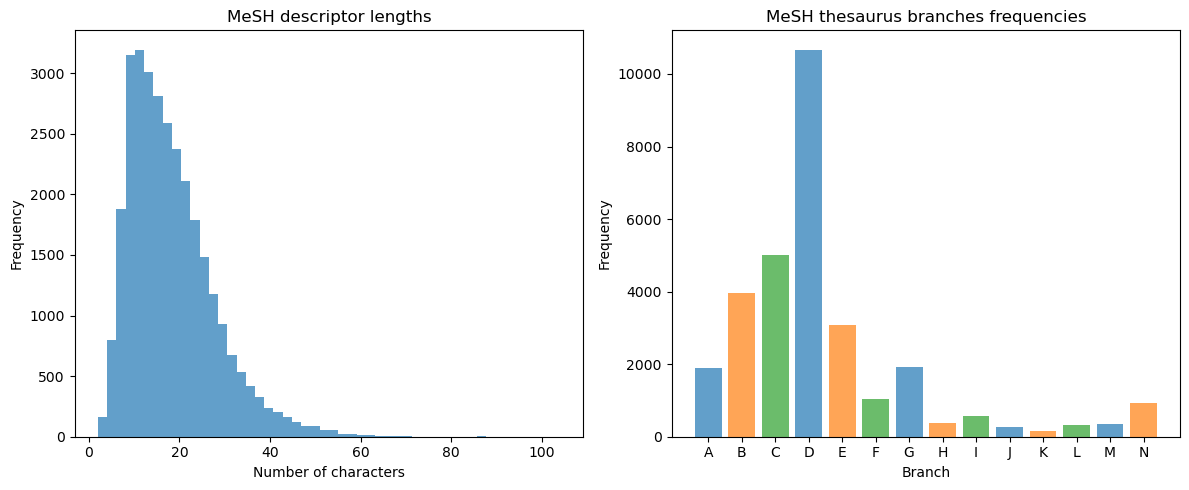

In [11]:
# Compute the character lengths of each MeSH descriptor title
MeSH_descriptors_lengths = [len(x) for x in MeSH_descriptors_titles]

# Count how many descriptors fall into each top-level branch
freq = Counter(MeSH_branches["MESH_BRANCH"])
labels = sorted(freq.keys())
counts = [freq[k] for k in labels]

# Side by side plots for quick vocabulary overview
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left : histogram of descriptors titles lengths (character count)
axes[0].hist(MeSH_descriptors_lengths, bins=50, alpha=0.7, color="C0")
axes[0].set_title("MeSH descriptor lengths")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Number of characters")

# Right : bar chart of descriptor counts per top-level branch
axes[1].bar(labels, counts, color=["C0", "C1", "C2"], alpha=0.7)
axes[1].set_title("MeSH thesaurus branches frequencies")
axes[1].set_ylabel("Frequency")
axes[1].set_xlabel("Branch")
plt.tight_layout()
plt.show()

- The distribution of descriptors lengths shows that most MeSH descriptors are fairly short terms (peaking around 10-15 characters). The tail extends to ~ 100 characters, there is a minority of long descriptors.  
- The thesaurus branch D (*Chemicals and Drugs*) is by far the most represented, with 10,669 descriptors (34.9% of total descriptors). Branches C (*Diseases*, 16.4%), B (*Organisms*, 12.9%), E (*Analytical, Diagnostic and Therapeutic Techniques, and Equipment*, 10.1%), G (*Phenomena and Processes*, 6.3%), A (*Anatomy*, 6.2%) are the next most populated. Remaining branches are sparse.  

## 2. Retrieve Key Events from the AOP-wiki SPARQL endpoint

This section connects to the AOP-wiki SPARQL endpoint to retrieve information about Key Events in AOPs.  
The workflow includes 3 main steps:   
- **Count total Key Events**: execute a SPARQL query to count all Key Events available on the AOP-wiki endpoint.  
- **Retrieve Key Events with descriptions**: queries for Key Events that have a publicly available description, along with their title, description and the AOP they belong to, then builds a Pandas Dataframe to store them.  
- **Retrieve Key Events without descriptions**: queries for Key Events that do **not** have a description and store them in a Pandas Dataframe.  

In [12]:
# Define the endpoint URL
aop_endpoint_url = "https://aopwiki.rdf.bigcat-bioinformatics.org/sparql/"

In [13]:
# Count the total number of Key Events (KEs) available on the AOP-wiki SPARQL endpoint.
query = """
SELECT (COUNT(DISTINCT ?ke) AS ?totalKE)
WHERE {
    ?ke a aopo:KeyEvent .
}
"""

# Initialise the SPARQL wrapper, submit the query, and request JSON back
sparql = SPARQLWrapper(aop_endpoint_url)
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Print the count (useful as a sanity check before starting the full retrieval)
for result in results["results"]["bindings"]:
    print(result["totalKE"]["value"] + " AOP Key Events are currently available on the AOP-wiki SPARQL endpoint.")

1583 AOP Key Events are currently available on the AOP-wiki SPARQL endpoint.


In [14]:
# Retrieve all Key Events that have a publicly available description.
# /!\ Not all KEs expose a dc:description, so this query will return fewer entries than the total KE count above.
query = """
SELECT ?ke ?ketitle ?description
WHERE {
    ?ke a aopo:KeyEvent .
    ?ke dc:title ?ketitle .
    ?ke dc:description ?description .
} 
"""

# Initialise the SPARQL wrapper, submit the query, and request JSON back
sparql = SPARQLWrapper(aop_endpoint_url)
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Parse the results into a flat list of dicts, one per KE
data = []
for result in results["results"]["bindings"]:
    ke_id = result["ke"]["value"]
    ke_title = result["ketitle"]["value"]
    ke_description = result["description"]["value"]
    data.append({
        "KE_ID" : ke_id,
        "KE_TITLE" : ke_title,
        "KE_DESCRIPTION" : ke_description
    })

# Load results into a DataFrame (one row per KE)
AOP_KEs_description = pd.DataFrame(data)

# Report how many KEs have a description
unique_ke_ids = AOP_KEs_description["KE_ID"].unique()
print(f"{len(unique_ke_ids)} Key Events have publicly available descriptions.")

631 Key Events have publicly available descriptions.


In [15]:
# Retrieve all Key Events that do NOT have a publicly available description.
# FILTER NOT EXISTS excludes any KE for which a dc:description triple exists.
query = """
SELECT ?ke ?ketitle 
WHERE {
    ?ke a aopo:KeyEvent .
    ?ke dc:title ?ketitle .
    FILTER NOT EXISTS { ?ke dc:description ?d . }
} 
"""

# Initialise the SPARQL wrapper, submit the query, and request JSON back
sparql = SPARQLWrapper(aop_endpoint_url)
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Parse the results into a flat list of dicts, one per KE
data = []
for result in results["results"]["bindings"]:
    ke_id = result["ke"]["value"]
    ke_title = result["ketitle"]["value"]
    data.append({
        "KE_ID" : ke_id,
        "KE_TITLE" : ke_title
    })

# Load results into a DataFrame (one row per KE)
AOP_KEs_no_description = pd.DataFrame(data)

# Report the count
unique_ke_ids = AOP_KEs_no_description["KE_ID"].unique()
print(f"{len(unique_ke_ids)} Key Events do not have a publicly available description.")

952 Key Events do not have a publicly available description.


In [16]:
# Retrieve the AOP(s) each Key Event belongs to via the dcterms:isPartOf predicate.
# A single KE can be shared across multiple AOPs.
query = """
SELECT ?ke ?aop ?aoptitle
WHERE {
    ?ke a aopo:KeyEvent .
    ?ke dcterms:isPartOf ?aop .
    ?aop dc:title ?aoptitle
} 
"""

# Initialise the SPARQL wrapper, submit the query, and request JSON back
sparql = SPARQLWrapper(aop_endpoint_url)
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Parse results into a flat list of dicts, one row per (KE, AOP) pair
data = []
for result in results["results"]["bindings"]:
    ke_id = result["ke"]["value"]
    ke_aop = result["aop"]["value"]
    aop_title = result["aoptitle"]["value"]
    data.append({
        "KE_ID" : ke_id,
        "AOP_ID" : ke_aop,
        "AOP_TITLE" : aop_title
    })

# Load results into a DataFrame
KE_to_AOP = pd.DataFrame(data)

Before performing further analyses, we convert the retrieved Key Events data (titles and descriptions) into lists for easier manipulation, filtering, and iteration in subsequent steps. We also check the length distributions of the title and description Strings.

In [17]:
# Prepare lists
ke_titles_description = AOP_KEs_description["KE_TITLE"].unique().tolist()
ke_titles_no_description = AOP_KEs_no_description["KE_TITLE"].unique().tolist()
ke_descriptions = AOP_KEs_description["KE_DESCRIPTION"].unique().tolist()

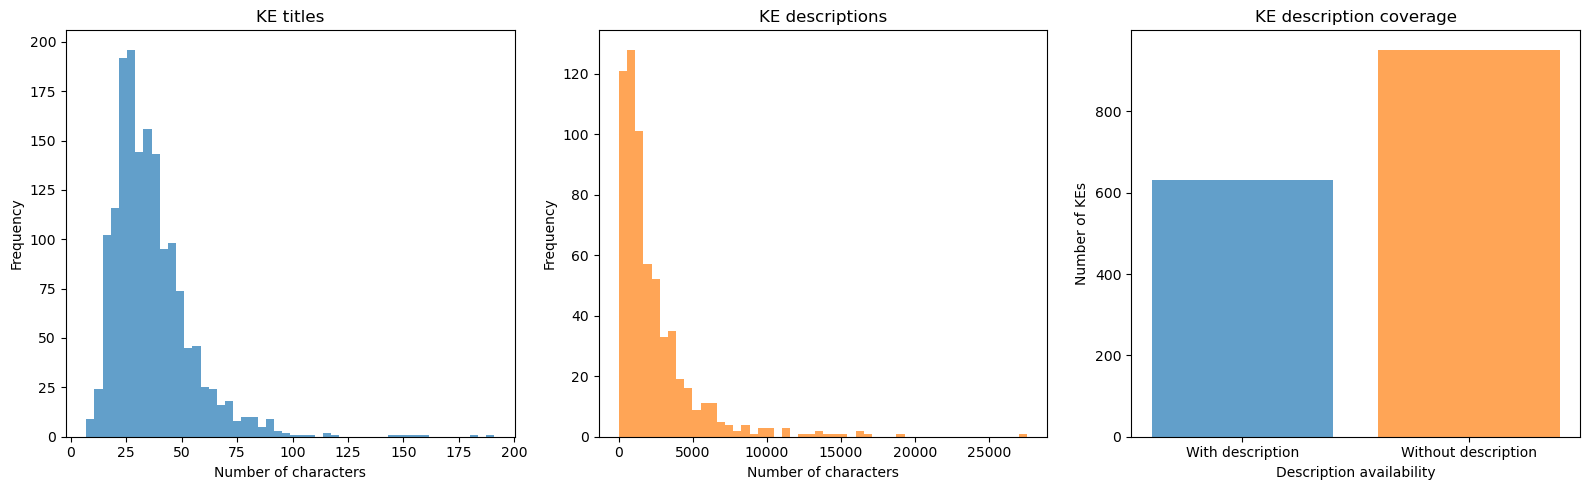

In [18]:
# Compute character lengths for KE titles (across all KEs) and descriptions (publicly available KEs only)
ke_titles_lengths = [len(x) for x in ke_titles_description + ke_titles_no_description]
ke_descriptions_lengths = [len(x) for x in ke_descriptions]

# Count KEs with and without descriptions for the coverage bar chart
n_with = len(ke_titles_description)
n_without = len(ke_titles_no_description)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left : distribution of KE title lengths
axes[0].hist(ke_titles_lengths, bins=50, alpha=0.7, color="C0")
axes[0].set_title("KE titles")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Number of characters")

# Middle : distribution of KE description lengths
axes[1].hist(ke_descriptions_lengths, bins=50, alpha=0.7, color="C1")
axes[1].set_title("KE descriptions")
axes[1].set_ylabel("Frequency")
axes[1].set_xlabel("Number of characters")

# Right : bar chart of KEs with vs without a public description
axes[2].bar(["With description", "Without description"], [n_with, n_without], color=["C0", "C1"], alpha=0.7)
axes[2].set_title("KE description coverage")
axes[2].set_ylabel("Number of KEs")
axes[2].set_xlabel("Description availability")

plt.tight_layout()
plt.show()

## 3. Indexing on Key Events with publicly available descriptions

In this section, we build an indexer to retrieve relevant standardised MeSH (Medical Subject Headings) descriptors based on Key Events. This is applied only to Key Events that have a publicly available description, since the indexing relies on textual content.  
We use the [Wellcome/WellcomeBertMesh](https://huggingface.co/Wellcome/WellcomeBertMesh) model as the underlying annotator. This model is based on [BiomedBERT](https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract) and was originally trained in the BioASQ competition to annotate biomedical texts with MeSH descriptors. While it was designed for research grants, it generalises well to any biomedical text, including AOP Key Event descriptions.

- **Input**: a Dataframe containing Key Events descriptions. For each Key Event, we use the description as input.  
- **Process**:
    - Each Key Event description is tokenised using the WellcomeBertMesh tokenizer, with padding and truncation to a fixed length.  
    - The tonekised text is fed into the WellcomeBertMesh, and predictions are generated.  
    - The model outputs predicted MeSH descriptors for the Key Event description.  
- **Output**: a list of dictionaires where each entry contains the Key Event ID and a list of predicted MeSH descriptors associated with that Key Event.

In [19]:
# Load the WellcomeBertMesh tokenizer and model from the Hugging Face Hub
wellcomeBertMesh_tokenizer = AutoTokenizer.from_pretrained("Wellcome/WellcomeBertMesh")
wellcomeBertMesh_model = AutoModel.from_pretrained("Wellcome/WellcomeBertMesh", trust_remote_code = True)
# trust_remote_code = True is required as the model uses custom inference logic hosted on the Hub

Some weights of the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract were not used when initializing BertModel: ['cls.predictions.decoder.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [21]:
def chunk_text(text, tokenizer, chunk_size=512, overlap=50):
    """Split token IDs into overlapping chunks of chunk_size."""
    
    # Suppress the spurious 'sequence longer than max_length' warning
    # We are intentionally encoding the full text before manually chunking it
    prev_verbosity = hf_logging.get_verbosity()
    hf_logging.set_verbosity_error()
    tokens = tokenizer.encode(text, add_special_tokens=False)
    hf_logging.set_verbosity(prev_verbosity)  # restore original verbosity

    chunks = []
    step = chunk_size - overlap - 2  # reserve 2 tokens for [CLS] and [SEP]
    for start in range(0, len(tokens), step):
        chunk = tokens[start : start + chunk_size - 2]
        chunks.append(chunk)
        if start + chunk_size - 2 >= len(tokens):
            break
    return chunks

def predict_long_text(text, model, tokenizer, chunk_size=512, overlap=50):
    """Run inference on each chunk and union all predicted MeSH labels."""
    chunks = chunk_text(text, tokenizer, chunk_size, overlap)
    all_labels = set()

    for chunk_ids in chunks:
        # Re-add special tokens and pad to max_length
        inputs = tokenizer.prepare_for_model(
            chunk_ids,
            padding="max_length",
            truncation=True,
            max_length=chunk_size,
            return_tensors="pt"
        )
        # Add batch dimension
        inputs = {k: v.unsqueeze(0) for k, v in inputs.items()}

        labels = model(**inputs, return_labels=True)
        all_labels.update(labels[0])

    return list(all_labels)

In [22]:
indexing_results = []

# Set the model to evaluation mode : disables dropout and other training-specific layers
wellcomeBertMesh_model.eval()

# Disable gradient computation since we are doing inference only, not training. This reduces memory usage and speeds up the forward pass.
with torch.no_grad():
    for _, row in AOP_KEs_description.iterrows():
        id = row["KE_ID"]
        description = row["KE_DESCRIPTION"]

        # Forward pass : return_labels = True triggers the model's built-in thresholding logic, returning predicted MeSH descriptor titles directly instead of raw logits
        labels = labels = predict_long_text(
            description,
            wellcomeBertMesh_model,
            wellcomeBertMesh_tokenizer
        )

        indexing_results.append({
            "KE_ID": id,
            "MESH_TITLES": labels 
        })

You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


In [23]:
# Flatten the nested list into a list of dictionaries : one row per KE / MeSH pair.
indexing_results_flatten = []
for entry in indexing_results :
    ke_id = entry["KE_ID"]
    for mesh in entry["MESH_TITLES"] :
        indexing_results_flatten.append({'KE_ID' : ke_id, 'MESH_TITLE' : mesh})

# Convert the flattened list into a DataFrame for easier manipulation and analysis
indexing_results_dataframe = pd.DataFrame(indexing_results_flatten)

In [24]:
# Merge with the MeSH descriptors dataframe to map each MESH_TITLE to the corresponding MESH_ID
indexing_results_dataframe = MeSH_descriptors.merge(indexing_results_dataframe, on = "MESH_TITLE")

# Merge with the MeSH branches dataframe to map each MESH_ID to the corresponding thesaurus branch
indexing_results_dataframe = MeSH_branches.merge(indexing_results_dataframe, on = "MESH_ID")

# Merge with the AOP KE dataframe to map each KE_TITLE to the corresponding KE_ID
indexing_results_dataframe = AOP_KEs_description[["KE_ID", "KE_TITLE"]].merge(indexing_results_dataframe, on = "KE_ID")

In [25]:
# Create a baseline dictionary 
baseline = indexing_results_dataframe.groupby("KE_ID")["MESH_ID"].apply(set)

# Calculate the number of unique MeSH IDs associated with each KE_ID.
num_mesh_per_ke = baseline.apply(len)

# Print summary statistics
print("Min number of mesh IDs per KE:", num_mesh_per_ke.min())
print("Max number of mesh IDs per KE:", num_mesh_per_ke.max())
print("Mean:", num_mesh_per_ke.mean())
print("Median:", num_mesh_per_ke.median())

Min number of mesh IDs per KE: 1
Max number of mesh IDs per KE: 40
Mean: 9.285714285714286
Median: 8.0


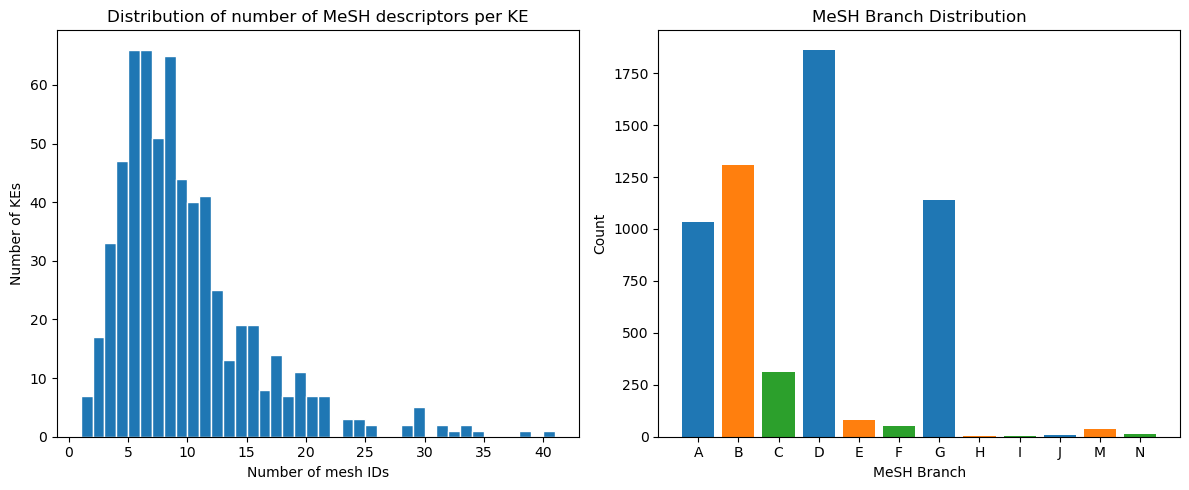

In [26]:
# Count the frequency of each MeSH thesaurus branch in the dataset
freq = Counter(indexing_results_dataframe["MESH_BRANCH"])
labels = sorted(freq.keys())
counts = [freq[k] for k in labels]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left : histogram of the number of annotated MeSH per KE
axes[0].hist(num_mesh_per_ke, bins=range(1, num_mesh_per_ke.max()+2), edgecolor='white', color = "C0")
axes[0].set_title("Distribution of number of MeSH descriptors per KE")
axes[0].set_xlabel("Number of mesh IDs")
axes[0].set_ylabel("Number of KEs")

# Right : bar chart of MeSH thesaurus branch frequencies
axes[1].bar(labels, counts, color=["C0", "C1", "C2"])
axes[1].set_xlabel("MeSH Branch")
axes[1].set_ylabel("Count")
axes[1].set_title("MeSH Branch Distribution")

plt.tight_layout()
plt.show()

- The distribution of the number of MeSH descriptors per KE appears roughly normal, with most KEs having between 5 and 10 associated MeSH descriptors, suggesting a balanced annotation process by the indexer.     
- The thesaurus branch D (*Chemicals and Drugs*), B (*Organsims*), G (*Phenomena and Processes*), and A (*Anatomy*) are the most frequent, with some changes in proportion compared to the most represented branches in the complete set of active MeSH descriptors. The dominance of these branches indicates a focus on diseases, organisms, and biological processes in the dataset.

In [27]:
# Get the set of all unique MeSH thesaurus branches in the dataset.
all_branches = set(MeSH_branches["MESH_BRANCH"].unique())

# Get the set of MeSH branches actually present in the indexing results.
used_branches = set(indexing_results_dataframe["MESH_BRANCH"].unique())

# Identify branches that are not present in the indexing results. 
empty_branches = all_branches - used_branches
print(empty_branches)

{'K', 'L'}


Branches K (*Humanities*) and L (*Information Science*) are not present in teh indexing results dataset. We'll need to remove them for the manual matching of KEs lacking a publicly available description.

For Key Events (KEs) lacking publicly available descriptions, we need an alternative method to associate them with MeSH terms. Our first approach was to index only the KE titles.  

## 4. Indexing on Key Event titles

We performed indexing on KEs that do have a publicly available descriptions, from their titles only. This will allow us to compare the results with the previous indexing (which used descriptions), that we will consider from now on as ground truth for validation. 

In [28]:
indexing_results_titles = []

# Set the model to evaluation mode : disables dropout and other training-specific layers
wellcomeBertMesh_model.eval()

# Disable gradient computation since we are doing inference only, not training. This reduces memory usage and speeds up the forward pass.
with torch.no_grad():
    for _, row in AOP_KEs_description.iterrows():
        id = row["KE_ID"]
        description = row["KE_TITLE"]

        # Tokenise the KE description with padding and truncation to the model's maximum input length
        inputs = wellcomeBertMesh_tokenizer(
            [description],
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Forward pass : return_labels = True triggers the model's built-in thresholding logic, returning predicted MeSH descriptor titles directly instead of raw logits
        labels = wellcomeBertMesh_model(**inputs, return_labels=True)

        indexing_results_titles.append({
            "KE_ID": id,
            "MESH_TITLES": labels[0] # labels[0] is the list of predicted MeSH titles for this KE
        })

In [29]:
# Flatten the nested list into a list of dictionaries : one row per KE / MeSH pair.
indexing_results_flatten = []
for entry in indexing_results_titles :
    ke_id = entry["KE_ID"]
    for mesh in entry["MESH_TITLES"] :
        indexing_results_flatten.append({'KE_ID' : ke_id, 'MESH_TITLE' : mesh})

# Convert the flattened list into a DataFrame for easier manipulation and analysis
indexing_results_dataframe_titles = pd.DataFrame(indexing_results_flatten)

In [30]:
# Merge with the MeSH descriptors dataframe to map each MESH_TITLE to the corresponding MESH_ID
indexing_results_dataframe_titles = MeSH_descriptors.merge(indexing_results_dataframe_titles, on = "MESH_TITLE")

# Merge with the MeSH branches dataframe to map each MESH_ID to the corresponding thesaurus branch
indexing_results_dataframe_titles = MeSH_branches.merge(indexing_results_dataframe_titles, on = "MESH_ID")

# Merge with the AOP KE dataframe to map each KE_TITLE to the corresponding KE_ID
indexing_results_dataframe_titles = AOP_KEs_description[["KE_ID", "KE_TITLE"]].merge(indexing_results_dataframe_titles, on = "KE_ID")

In [31]:
# Create a baseline dictionary 
baseline_titles = indexing_results_dataframe_titles.groupby("KE_ID")["MESH_ID"].apply(set)

# Calculate the number of unique MeSH IDs associated with each KE_ID.
num_mesh_per_ke = baseline_titles.apply(len)

# Print summary statistics
print("Min number of mesh IDs per KE:", num_mesh_per_ke.min())
print("Max number of mesh IDs per KE:", num_mesh_per_ke.max())
print("Mean:", num_mesh_per_ke.mean())
print("Median:", num_mesh_per_ke.median())

Min number of mesh IDs per KE: 1
Max number of mesh IDs per KE: 8
Mean: 2.6714285714285713
Median: 3.0


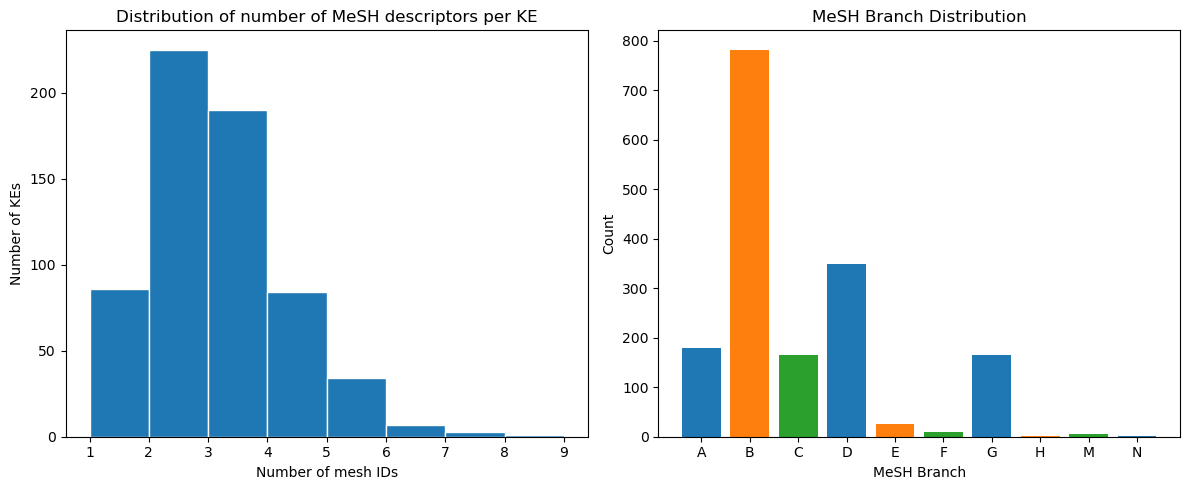

In [32]:
# Count the frequency of each MeSH thesaurus branch in the dataset
freq = Counter(indexing_results_dataframe_titles["MESH_BRANCH"])
labels = sorted(freq.keys())
counts = [freq[k] for k in labels]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left : histogram of the number of annotated MeSH per KE
axes[0].hist(num_mesh_per_ke, bins=range(1, num_mesh_per_ke.max()+2), edgecolor='white', color = "C0")
axes[0].set_title("Distribution of number of MeSH descriptors per KE")
axes[0].set_xlabel("Number of mesh IDs")
axes[0].set_ylabel("Number of KEs")

# Right : bar chart of MeSH thesaurus branch frequencies
axes[1].bar(labels, counts, color=["C0", "C1", "C2"])
axes[1].set_xlabel("MeSH Branch")
axes[1].set_ylabel("Count")
axes[1].set_title("MeSH Branch Distribution")

plt.tight_layout()
plt.show()

The indexing on KE titles only associated less MeSH descriptors to each Key Event (median = 3 vs. median = 7 for indexing with descriptions). The most represented MeSH thesaurus branch is the branch B (Organisms), which is very different from the previous indexing results, and might no seem as informative regarding diseases or biological processes. 

# 5. Export result datatable

## Export as TSV

In [ ]:
# Concatenate all results together
# Columns : AOP ID | AOP TITLE | KE ID | KE TITLE | MESH ID | MESH TITLE

# Indexing on descriptions
indexing = indexing_results_dataframe[["MESH_ID", "KE_ID"]]
indexing = MeSH_descriptors.merge(indexing, on = "MESH_ID")
indexing = AOP_KEs_description[["KE_ID", "KE_TITLE"]].merge(indexing, on = "KE_ID")
indexing = KE_to_AOP.merge(indexing, on = "KE_ID")
indexing = indexing[["AOP_ID", "AOP_TITLE", "KE_ID", "KE_TITLE", "MESH_ID", "MESH_TITLE"]]

In [ ]:
# Indexing on titles
indexing_titles = indexing_results_dataframe_titles[["MESH_ID", "KE_ID"]]
indexing_titles = MeSH_descriptors.merge(indexing_titles, on = "MESH_ID")
indexing_titles = AOP_KEs_no_description[["KE_ID", "KE_TITLE"]].merge(indexing_titles, on = "KE_ID")
indexing_titles = KE_to_AOP.merge(indexing_titles, on = "KE_ID")
indexing_titles = indexing_titles[["AOP_ID", "AOP_TITLE", "KE_ID", "KE_TITLE", "MESH_ID", "MESH_TITLE"]]

In [ ]:
AOP_MeSH_mappings = pd.concat([indexing, indexing_titles], ignore_index=True)

In [ ]:
# Export mapping results
AOP_MeSH_mappings.to_csv("aop_mesh_mappings.tsv", sep = "\t", index = False)

## Export as RDF/XML

In [ ]:
# Create an RDF graph object and define biolink namespace
g = Graph()
BIOLINK = Namespace("https://w3id.org/biolink/vocab/")
AOPO = Namespace("http://aopkb.org/aop_ontology#")
MESH = Namespace("http://id.nlm.nih.gov/mesh/")
g.bind("biolink", BIOLINK)
g.bind("aopo", AOPO)
g.bind("mesh", MESH)

In [ ]:
# Iterate rows and add triples from AOP - MeSH mappings
for row in AOP_MeSH_mappings.iterrows():
    g.add((
        URIRef(row[1]["AOP_ID"]),
        RDF.type,
        AOPO.AdverseOutcomePathway
    ))
    g.add((
        URIRef(row[1]["AOP_ID"]),
        DC.title,
        Literal(row[1]["AOP_TITLE"], datatype = XSD.string)
    ))
    g.add((
        URIRef(row[1]["KE_ID"]),
        RDF.type,
        AOPO.KeyEvent
    ))
    g.add((
        URIRef(row[1]["KE_ID"]),
        DCTERMS.isPartOf,
        URIRef(row[1]["AOP_ID"])
    ))
    g.add((
        URIRef(row[1]["KE_ID"]),
        DC.title,
        Literal(row[1]["KE_TITLE"], datatype = XSD.string)
    ))
    g.add((
        URIRef(row[1]["KE_ID"]),
        BIOLINK.related_to,
        URIRef(row[1]["MESH_ID"])
    ))
    g.add((
        URIRef(row[1]["MESH_ID"]),
        RDF.type,
        MESH.TopicalDescripor
    ))
    g.add((
        URIRef(row[1]["MESH_ID"]),
        # RDFS.label, = what is the MeSH RDF, dc:title to unify schema w/ AOP RDF
        DC.title,
        Literal(row[1]["MESH_TITLE"], datatype = XSD.string)
    ))

In [ ]:
g.serialize(destination = "test_export.rdf", format = "xml")

<Graph identifier=Ndfc1cad418fe4c638b20f97779443958 (<class 'rdflib.graph.Graph'>)>

# 6. Evaluate performance compared to description-based indexing

In this section, we evaluated the performance of title-based indexing by comparing it to our ground truth (description-based indexing).  

## Exact match comparison

**Methodology**:  
- True Positives (TP): MeSH-KE pairs identified in both title-based and description-based indexing.  
- False Positives (FP): MeSH-KE pairs identified in title-based indexing but missing in the ground truth.  
- False Negatives (FN): MeSH-KE pairs present in the ground truth, but missed in the title-based indexing.  
  
**Metrics**:  
- Precision: Measures the accuracy of title-based indexing (TP / (TP + FP))  
- Recall: Measures the coverage of title-based indexing (TP / (TP + FN))
- F1 Score: Harmonic mean of precision and recall, providing a balanced performance metric

In [33]:
def evaluation_metrics(baseline, results) :
    """
    Evaluate the performance of a MeSH indexing method by comparing it to a baseline (ground truth).

    This function calculates precision, recall, and F1 score for the predicted MeSH-KE pairs
    against a baseline dataset. It identifies True Positives (TP), False Positives (FP), and
    False Negatives (FN) to assess the accuracy and coverage of the indexing method.

    Parameters:
    -----------
    baseline : pandas.DataFrame
        The ground truth DataFrame containing columns "MESH_ID" and "KE_ID".
    results : pandas.DataFrame
        The DataFrame containing the predicted MeSH-KE pairs to evaluate, with columns "MESH_ID" and "KE_ID".

    Outputs:
    --------
    Prints the following metrics:
        - TP: Number of True Positives.
        - FP: Number of False Positives.
        - FN: Number of False Negatives.
        - Precision: Ratio of TP to (TP + FP).
        - Recall: Ratio of TP to (TP + FN).
        - F1 Score: Harmonic mean of precision and recall.
    """
    # Create sets of (MESH_ID, KE_ID) pairs for both ground truth (baseline) and results datasets.
    # This allows for efficient set operations to identify matches and mismatches.
    baseline_pairs = set(zip(baseline["MESH_ID"], baseline["KE_ID"]))
    result_pairs = set(zip(results["MESH_ID"], results["KE_ID"]))
    

    # Compute the confusion matrix components : 
    # - True Positive (TP) : pairs present in both baseline and results.
    # - False Positives (FP) :  pairs present in results but not in baseline
    # - False Negatives (FN) : pairs present in baseline but not in results
    tp = len(result_pairs & baseline_pairs)
    fp = len(result_pairs - baseline_pairs)
    fn = len(baseline_pairs - result_pairs)
    
    # Prepare lists for precision, recall, and F1 score calculation.
    # y_true = ground truth labels (1 for TP and FN, 0 for FP)
    # y_pred = predicted labels (1 for TP and FP, 0 for FN)
    y_true = [1]*tp + [0]*fp + [1]*fn
    y_pred = [1]*tp + [1]*fp + [0]*fn
    
    # Calculate precision, recall, and F1 score using sklearn.metrics.
    precision = metrics.precision_score(y_true, y_pred)
    recall = metrics.recall_score(y_true, y_pred)
    f1 = metrics.f1_score(y_true, y_pred)
    
    # Print the results
    print(f"TP: {tp}")
    print(f"FP: {fp}")
    print(f"FN: {fn}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")

In [34]:
# Evaluate the title-based indexing results against the ground truth (description-based indexing)
evaluation_metrics(indexing_results_dataframe, indexing_results_dataframe_titles)

TP: 1199
FP: 484
FN: 4651
Precision: 0.712
Recall: 0.205
F1 Score: 0.318


The title-based indexing:  
- correctly identified 1,102 MeSH-KE pairs that were also identified by the description-based indexing,  
- incorrectly assigned 563 MeSH-KE pairs that were not present in the baseline,  
- missed 3,101 MeSH-KE pairs that were present in the baseline.  
This suggests some over-indexing or noise and a significant under-coverage when relying solely on title.  
  
0.662 precision means that 66.2% of the MeSh-KE pairs predicted by the title-based indexing were correct, when the model predicts a MeSH term for a KE, it is correct 66.2% of times.  
0.262 recall means that the title-based indexing only captured 26.2% of the MeSH-KE pairs, indicating that most relevant MeSH terms are missed when using titles alone.
A F1 score of 0.376 indicates that the low recall is dragging down the overall performance.

## Similarity-based comparison

- extract just mesh ID (DXXX) from MESH_ID
- similarity scores : embeddings from https://github.com/helboukkouri/mesh-embeddings (node2vec)
- Gale and Shapley : stable marriage algorithm with tweaks : score threshold for proposal and polygamy
- % matched, % unmatched (in baseline and prediction), avg similarity

In [43]:
with open('mesh_ui_to_id.pickle', 'rb') as stream:
    mesh_ui_to_id = pickle.load(stream)

embeddings = {}

with gzip.open('mesh_embeddings.txt.gz', 'rt') as stream:
    n_embeddings, embedding_dim = stream.readline().strip().split()
    for line in stream:
        splitline = str(line).strip().split()
        idx = int(splitline[0])
        vector = list(map(float, splitline[1:]))
        embeddings[idx] = vector

In [44]:
def get_embedding_from_mesh_ui(mesh_ui):
    idx = mesh_ui_to_id.get(mesh_ui)
    return embeddings[idx] if idx is not None else None

In [52]:
def cosine_similarity_1d(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [46]:
def cosine_similarity_matrix(mesh_set_a, mesh_set_b):
    emb_a = [get_embedding_from_mesh_ui(ui) for ui in mesh_set_a]
    emb_b = [get_embedding_from_mesh_ui(ui) for ui in mesh_set_b]

    # Filter out None BEFORE converting to np.array
    emb_a = [e for e in emb_a if e is not None]
    emb_b = [e for e in emb_b if e is not None]

    if not emb_a or not emb_b:
        return np.array([])

    return cosine_similarity(np.array(emb_a), np.array(emb_b))

In [47]:

def stableMarriage(baseline_mesh_set, pred_mesh_set):

    # SIMILARITY MATRIX
    # sim_matrix[i, j] = cosine similarity between baseline_mesh_set[i] and pred_mesh_set[j]
    # shape : (n, m)
    sim_matrix = cosine_similarity_matrix(baseline_mesh_set, pred_mesh_set)

    if sim_matrix.size == 0:
        return {}, list(baseline_mesh_set), list(pred_mesh_set)
    if sim_matrix.size == 0:
        return {}, list(baseline_mesh_set), list(pred_mesh_set)
     
    n = sim_matrix.shape[0]
    m = sim_matrix.shape[1]

    # PREFERENCE LISTS
    # prefs_baseline[a] : list of b indices sorted by decreasing similarity to a = the order in which a will "propose" to b
    # prefs_pred[b] : list of a indices sorted by decreasing similarity to b = b's preference ordering over a = used to decide to accept / reject "proposal"
    prefs_baseline = [list(np.argsort(row)[::-1]) for row in sim_matrix]
    prefs_pred     = [list(np.argsort(col)[::-1]) for col in sim_matrix.T]

    # rank_pred[b][a] = rank of a in b's preference list (mower = more preferred)
    # recomputed for O(1) lookup during the proposal loop, instead of scanning prefs_pred[b]
    rank_pred      = [{a: rank for rank, a in enumerate(prefs)} for prefs in prefs_pred]

    # INITIALISATION
    free_baseline  = list(range(n)) # all baseline items start unmatched and will propose
    next_prop      = [0] * n        # next_prop[a] = index of the next b to propose to in prefs_baseline[a]
    match_baseline = [None] * n     # match_baseline[a] = index of b currently matched to a (or None)
    match_pred     = [None] * m     # match_pred[b] = index of a currently matched to b (or None)

    # PROPOSAL LOOP : only for monogamy (low_threshold ≤ sim < high_threshold)
    # items with a high-threshold match are handled separately after
    while free_baseline :
        a = free_baseline.pop(0)    # pick any free baseline item to propose

        # if it has already proposed to every b and was rejected by all : stays unmatched
        if next_prop[a] >= len(prefs_baseline[a]) :
            # a has proposed to everyone and found no match → leave unmatched
            continue
        
        # a proposes to its most preferred b it hasn't proposed to yet
        b = prefs_baseline[a][next_prop[a]]
        next_prop[a] += 1   # a won't propose to b again regardless of outcome

        # if best remaining candidate is below threshold, a stays unmatched
        if sim_matrix[a, b] < 0.5 :
            continue

        # monogamy range : standard Gale Shapley algorithm    
        if match_pred[b] is None :
            # b is currently unmatched = b accepts unconditionnally
            match_baseline[a] = b
            match_pred[b] = a

        else :
            # b is already matched to a_current = b compares a and a_current
            a_current = match_pred[b]

            if rank_pred[b][a] < rank_pred[b][a_current] :
                # b prefers the new proposer a over its current partner = b swaps partner
                # but also check that a is good enough (similarity threshold)
                if sim_matrix[a, b] >= 0.5 :
                    match_baseline[a] = b
                    match_pred[b] = a
                    match_baseline[a_current] = None
                    free_baseline.append(a_current)
                else :
                    free_baseline.append(a)
            else :
                # b prefers its current partner = b rejects a
                free_baseline.append(a) # a remains free and will propose to its next candidate

    # POLYGAMY PASS : collect all b's above high_threshold for each a
    poly_matches = {
        a: [b for b in range(m) if sim_matrix[a, b] >= 0.9]
        for a in range(n)
    }

    # BUILD OUTPUT
    # Start from monogamy matches, then extend with poly matches
    matched = {}
    for a in range(n):
        partners = []

        # Add monogamy match if it exists
        if match_baseline[a] is not None:
            partners.append(pred_mesh_set[match_baseline[a]])

        # Add any high-similarity poly matches (avoid duplicating the monogamy match)
        for b in poly_matches[a]:
            pred_item = pred_mesh_set[b]
            if pred_item not in partners:
                partners.append(pred_item)

        if partners:
            matched[baseline_mesh_set[a]] = partners  # list of matched pred items

    unmatched_a = [baseline_mesh_set[a] for a in range(n) if not matched.get(baseline_mesh_set[a])]

    matched_bs = set(
        b for a in range(n)
        for b in ([match_baseline[a]] if match_baseline[a] is not None else []) + poly_matches[a]
    )
    unmatched_b = [pred_mesh_set[b] for b in range(m) if b not in matched_bs]

    return matched, unmatched_a, unmatched_b

In [48]:
# Extract MeSH ID from URL
indexing_results_dataframe["MESH_ID"] = indexing_results_dataframe["MESH_ID"].str.split("/").str[-1]
indexing_results_dataframe_titles["MESH_ID"] = indexing_results_dataframe_titles["MESH_ID"].str.split("/").str[-1]

In [56]:
def mesh_similarity_stats(baseline_meshes, pred_meshes):
    emb_a = [get_embedding_from_mesh_ui(ui) for ui in baseline_meshes]
    emb_b = [get_embedding_from_mesh_ui(ui) for ui in pred_meshes]

    emb_a = [e for e in emb_a if e is not None]
    emb_b = [e for e in emb_b if e is not None]

    if not emb_a or not emb_b:
        return None

    sim_matrix = cosine_similarity(np.array(emb_a), np.array(emb_b))
    return sim_matrix.mean(), sim_matrix.min(), sim_matrix.max()

In [57]:
def evaluate_matching(df_baseline, df_prediction) :
# Group MeSH IDs by KE
    baseline_groups = df_baseline.groupby("KE_ID")["MESH_ID"].apply(list)
    prediction_groups = df_prediction.groupby("KE_ID")["MESH_ID"].apply(list)

    all_ke_ids = set(baseline_groups.index) | set(prediction_groups.index)

    rows = []

    for ke_id in all_ke_ids :
        baseline_meshes = baseline_groups.get(ke_id, [])
        prediction_meshes = prediction_groups.get(ke_id, [])

        matching, unmatched_baseline, unmatched_prediction = stableMarriage(
                baseline_meshes, prediction_meshes
            )
        
        avg_sim, min_sim, max_sim = mesh_similarity_stats(baseline_meshes, prediction_meshes) or (None, None, None)

        # Count matched pairs (one baseline → one or more predictions)
        n_matched_pairs = sum(len(bs) for bs in matching.values())
        n_unmatched_b = len(unmatched_baseline)
        n_unmatched_p = len(unmatched_prediction)
        total = n_matched_pairs + n_unmatched_b + n_unmatched_p

        rows.append({
            "KE_ID"              : ke_id,
            "n_matched_pairs"    : n_matched_pairs,
            "n_unmatched_base"   : n_unmatched_b,
            "n_unmatched_pred"   : n_unmatched_p,
            "total"              : total,
            "avg_similarity": avg_sim,
            "min_similarity": min_sim,
            "max_similarity": max_sim,
            "pct_matched"        : round(100 * n_matched_pairs / total, 2) if total else 0,
            "pct_unmatched_base" : round(100 * n_unmatched_b   / total, 2) if total else 0,
            "pct_unmatched_pred" : round(100 * n_unmatched_p   / total, 2) if total else 0,
            })
        
    # Per KE DF
    df_per_ke = pd.DataFrame(rows).set_index("KE_ID").sort_index()

    # Summary across all KEs
    summary = df_per_ke[["pct_matched", "pct_unmatched_base", "pct_unmatched_pred", "avg_similarity"]].mean().rename({
        "pct_matched"        : "mean_pct_matched",
        "pct_unmatched_base" : "mean_pct_unmatched_baseline",
        "pct_unmatched_pred" : "mean_pct_unmatched_prediction",
        "avg_similarity"     : "avg_similarity"
    })

    return df_per_ke, summary

In [58]:
df_per_ke_titles, summary_titles = evaluate_matching(indexing_results_dataframe, indexing_results_dataframe_titles)

print(summary_titles.to_string())

mean_pct_matched                 31.361284
mean_pct_unmatched_baseline      61.389477
mean_pct_unmatched_prediction     7.249414
avg_similarity                    0.434794
